# ***Reducción de Dimensionalidad con UMAP***

Aplicar UMAP para transformar los datos escalados del dataset FIFA 22 a un espacio de dos dimensiones, con el objetivo de visualizar estructuras complejas, densidades y posibles agrupamientos que no son fácilmente detectables mediante PCA u otros métodos lineales. Estas visualizaciones sirven como apoyo para interpretar los resultados de clustering, identificar grupos naturales y explorar la distribución subyacente de los jugadores.

**Introducción**

Los métodos de reducción de dimensionalidad no lineales, como t-SNE y UMAP, permiten transformar datos de alta dimensionalidad en representaciones visuales de 2D o 3D, preservando en mayor o menor medida las relaciones entre los datos.

En este notebook exploraremos ambos métodos y analizaremos qué tan bien reflejan las relaciones entre las instancias del dataset FIFA 22, y cómo estas visualizaciones pueden complementar el análisis realizado con distintos algoritmos de clustering.

**¿Qué es la reducción de dimensionalidad?**

Es el proceso de convertir datos con muchas características (features) en un número menor de variables, pero manteniendo la mayor parte posible de la estructura original.

**¿Por qué necesitamos reducción de dimensionalidad?**

- los clustering funcionan en alta dimensionalidad pero nosotros como humanos no podemos visualizar más de 2D o 3D

- por eso usamos técnicas para “comprimir” los datos en 2D sin perder información importante

Esto NO afecta tus clusters, solo sirve para visualización e interpretación.


**Diferencias entre PCA, t-SNE y UMAP**

1. PCA
- lineal
- conserva variabilidad global
- rápido
-ideal para preprocesar

2. t-SNE (t-distributed Stochastic Neighbor Embedding)

- método no lineal
- preserva relaciones locales
- muy bueno para visualizar “grupitos naturales”
- puede deformar distancias globales
- tarda más tiempo

**Ideal para:**
- Ver si tus clusters se separan bien a nivel local.

3. UMAP (Uniform Manifold Approximation and Projection)

- más moderno
- preserva relaciones locales y globales
- más rápido que t-SNE
- produce separaciones más estables

**Ideal para:** 
Visualizaciones limpias de clusters y estructuras internas.

**¿Esto sirve para los clustering?**

t-SNE y UMAP no mejoran los clustering,
pero sí ayudan a evaluar visualmente si:

- KMeans formó clusters coherentes
- DBSCAN detectó densidades correctamente
- Hierarchical separa los grupos naturales
- Entre otros..

In [2]:
%load_ext kedro.ipython 
catalog.keys()
df_FIFA = catalog.load("model_input_table")

[03/07/26 17:34:48] INFO     Using                                                                  ]8;id=442285;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=212360;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\framework\project\__init__.py#270\270]8;;\
                             'C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\ke                
                             dro\framework\project\rich_logging.yml' as logging configuration.                     

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=470026;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=343040;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py#63\63]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=772248;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=221199;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py#65\65]8;;\

                    INFO     Resolved project path as: C:\Users\brand\Downloads\Proyecto_ML_Kedro.  ]8;id=878370;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=392621;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py#180\180]8;;\
                             To set a different path, run '%reload_kedro <project_root>'                           

2


[03/07/26 17:35:52] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=2738;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=578036;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro_telemetry\plugin.py#243\243]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/configuration/telemetry.html                         

[03/07/26 17:35:53] INFO     Kedro project machine_learning_project                                 ]8;id=244777;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=769607;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py#146\146]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=207746;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=69071;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py#147\147]8;;\
                             'pipelines'                                                                           

[03/07/26 17:35:57] INFO     Registered line magic 'run_viz'                                        ]8;id=412639;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=860296;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py#153\153]8;;\

[03/07/26 17:35:59] INFO     Loading data from model_input_table (ParquetDataset)...           ]8;id=77499;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=959580;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\io\data_catalog.py#1046\1046]8;;\

#### **Importaciónes**

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

### **Escalado**

Diferentes características pueden tener unidades y escalas diferentes, como el salario frente a la edad. Para compararlas de forma justa, el PCA primero estandariza los datos haciendo que cada característica tenga

- Una media de 0
- Una desviación estándar de 1

Tambien se observara los cambios de la varianza

### **Dataframe con variables escaladas**
Se usara este dataframe para PCA

In [ ]:
df_fifa_scaled.drop(columns=["Joined_Month","Joined_Day","Joined_Year"])

##### **Selección de features**

In [40]:
features = [

"Age",
"Overall",
"Potential",
"Special",
"International Reputation",
"Weak Foot",
"Skill Moves",
"Crossing",
"Finishing",
"HeadingAccuracy",
"ShortPassing",
"Volleys",
"Dribbling",
"Curve",
"FKAccuracy",
"LongPassing",
"BallControl",
"Acceleration",
"SprintSpeed",
"Agility",
"Reactions",
"Balance",
"ShotPower",
"Jumping",
"Stamina",
"Strength",
"LongShots",
"Aggression",
"Interceptions",
"Positioning",
"Vision",
"Penalties",
"Composure",
"Marking",
"StandingTackle",
"SlidingTackle",
"GKDiving",
"GKHandling",
"GKKicking",
"GKPositioning",
"GKReflexes",
"Best Overall Rating",
"DefensiveAwareness",
"Offensive_Skills",
"Defensive_Skills",
"Overall_Class_Bin",
"Height_cm",
"Weight_kg",
"Value_num",
"Wage_num",
"Release Clause_num",
]

"""
descartados
"Year",
"Jersey Number",

"""

# dataframe escalado
X = df_fifa_scaled[features]

#### **Escalar**

In [41]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### *(La creacion de estas seldas demoran mucho)*

##### **t-SNE básico (2D)**

In [42]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,  
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

X_tsne = tsne.fit_transform(X_scaled)

df_fifa_22["TSNE_1"] = X_tsne[:, 0]
df_fifa_22["TSNE_2"] = X_tsne[:, 1]

**t-SNE básico (2D)**

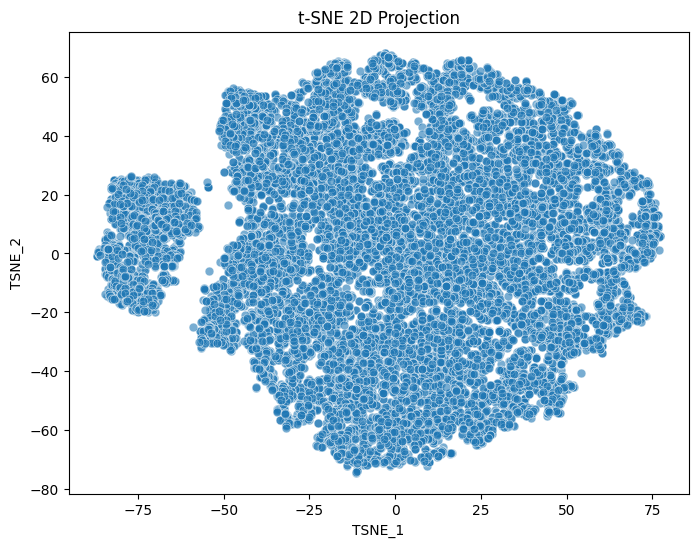

In [44]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="TSNE_1", y="TSNE_2", data=df_fifa_22, s=40, alpha=0.6)
plt.title("t-SNE 2D Projection")
plt.show()

#### **t-SNE con diferentes parámetros (Requisito de rúbrica)**

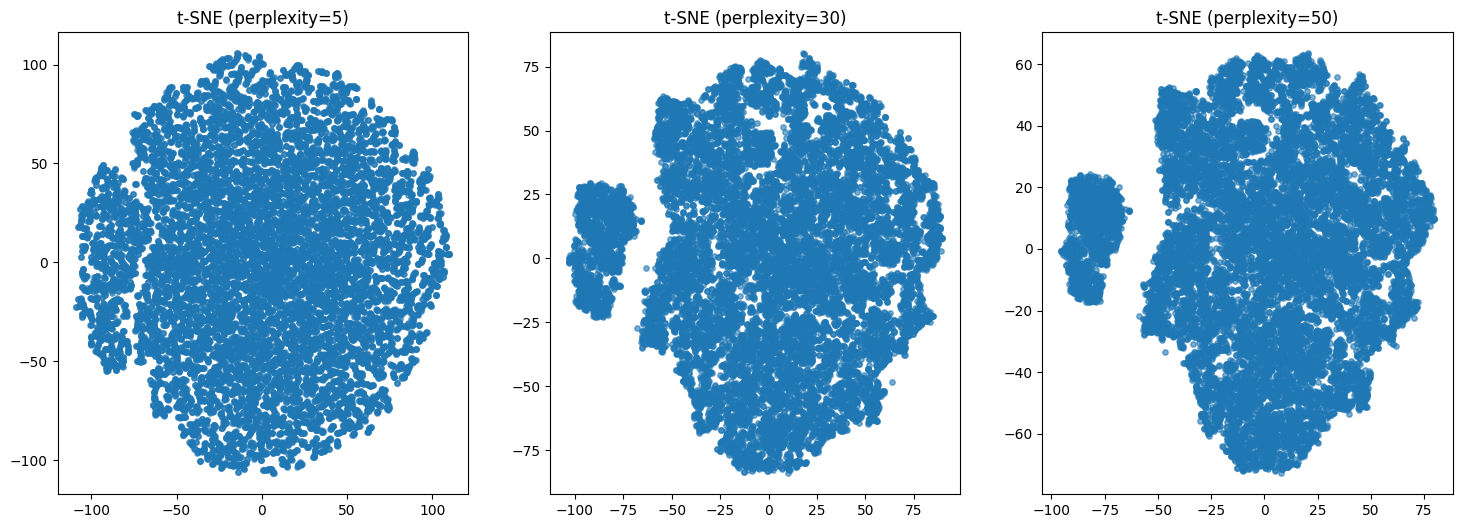

In [45]:
perplexities = [5, 10, 20]

fig, axes = plt.subplots(1, 3, figsize=(18,6))

for i, p in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=p, random_state=42)
    X_emb = tsne.fit_transform(X_scaled)

    axes[i].scatter(X_emb[:,0], X_emb[:,1], s=15, alpha=0.6)
    axes[i].set_title(f"t-SNE (perplexity={p})")

plt.show()


#### **Extra: t-SNE 3D (muy bueno para defensa)**

In [46]:
tsne_3d = TSNE(n_components=3, perplexity=30, random_state=42)
X_tsne_3d = tsne_3d.fit_transform(X_scaled)

df_fifa_22["TSNE_3D_1"] = X_tsne_3d[:,0]
df_fifa_22["TSNE_3D_2"] = X_tsne_3d[:,1]
df_fifa_22["TSNE_3D_3"] = X_tsne_3d[:,2]